**E-Commerce Sales Analysis using SQL & Python**

**Objective:** Analyze online retail sales data using SQL queries and visualize key business insights using Python.

**Dataset:** Online Retail Dataset — UCI Machine Learning Repository

**Tools:** Python | Pandas | SQLite | Matplotlib | Seaborn

 **Import libraries**

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" libraries ready hain!")

 libraries ready hain!


**Data Loading**

In [5]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1', on_bad_lines='skip')


In [6]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

Total rows: 541909
Total columns: 8

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [7]:
print(f"\nfirst 5 rows:")
df.head()


first 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**Exploring the Data**

In [8]:
print("= Dataset Info =")
print(df.info())

= Dataset Info =
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [9]:
print("\n= Missing Values =")
print(df.isnull().sum())


= Missing Values =
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [10]:
print("\n= Basic Stats =")
print(df.describe())


= Basic Stats =
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


**Data Cleaning**

In [11]:
# UnitPrice ko float mein convert karo
df['UnitPrice'] = df['UnitPrice'].astype(float)

print(f"UnitPrice dtype ab: {df['UnitPrice'].dtype}")
print(df['UnitPrice'].describe())

UnitPrice dtype ab: float64
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


In [12]:
print(df['UnitPrice'].dtype)

float64


In [13]:
print("=== UnitPrice Column ===")
print(df['UnitPrice'].describe())

print("\nSample values:")
print(df['UnitPrice'].head(20))

=== UnitPrice Column ===
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Sample values:
0     2.55
1     3.39
2     2.75
3     3.39
4     3.39
5     7.65
6     4.25
7     1.85
8     1.85
9     1.69
10    2.10
11    2.10
12    3.75
13    1.65
14    4.25
15    4.95
16    9.95
17    5.95
18    5.95
19    7.95
Name: UnitPrice, dtype: float64


In [14]:
# Woh rows dekho jahan UnitPrice float nahi hai
mask = pd.to_numeric(df['UnitPrice'], errors='coerce').isna()
print(f"Problematic rows: {mask.sum()}")
print(df[mask]['UnitPrice'].unique())

Problematic rows: 0
[]


In [15]:
# Missing CustomerID wali rows hatao
df.dropna(subset=['CustomerID'], inplace=True)

# Remove negative and zero quantity
df = df[df['Quantity'] > 0]

# Remove roes with unitPrice zero
df = df[df['UnitPrice'] > 0]

# make a TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Date column theek karo
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['Year'] = df['InvoiceDate'].dt.year

# CustomerID ko integer banao
df['CustomerID'] = df['CustomerID'].astype(int)

print(" Now Data is clean !")
print(f"Rows after cleaning: {len(df)}")
print(f"Total Revenue: £{df['TotalPrice'].sum():,.2f}")
df.head()


 Now Data is clean !
Rows after cleaning: 397884
Total Revenue: £8,911,407.90


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010


Total Revenu

In [16]:
print(f"Total Revenue: £{df['TotalPrice'].sum():,.2f}")

Total Revenue: £8,911,407.90


****SQL Database Setup****

In [17]:
# Memory mein SQLite database banao
conn = sqlite3.connect(':memory:')

# Clean dataframe ko SQL table mein convert karo
df.to_sql('sales', conn, if_exists='replace', index=False)

# Check karo ke table ban gayi
test = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM sales", conn)

print("SQL Database ready!")
print(f"Total rows in database: {test['total_rows'][0]}")

SQL Database ready!
Total rows in database: 397884


**SQL Queries — Business Questions**

In [18]:
# Helper function — baar baar kaam aayegi
def run_query(sql, title=""):
    result = pd.read_sql_query(sql, conn)
    print(f"\n{'='*40}")
    print(f"  {title}")
    print(f"{'='*40}")
    print(result.to_string(index=False))
    return result

# Query 1: Business ka overall overview
q1 = run_query("""
    SELECT
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        COUNT(DISTINCT CustomerID) AS total_customers,
        ROUND(SUM(TotalPrice), 2) AS total_revenue,
        ROUND(AVG(TotalPrice), 2) AS avg_order_value
    FROM sales
""", " Business Overview")


   Business Overview
 total_orders  total_customers  total_revenue  avg_order_value
        18532             4338      8911407.9             22.4


**Query 2: Top 10 Countries by Revenue**

In [19]:
# Query 2: Top 10 Countries by Revenue
q2 = run_query("""
    SELECT
        Country,
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        COUNT(DISTINCT CustomerID) AS total_customers,
        ROUND(SUM(TotalPrice), 2) AS revenue
    FROM sales
    GROUP BY Country
    ORDER BY revenue DESC
    LIMIT 10
""", " Top 10 Countries by Revenue")


   Top 10 Countries by Revenue
       Country  total_orders  total_customers    revenue
United Kingdom         16646             3920 7308391.55
   Netherlands            94                9  285446.34
          EIRE           260                3  265545.90
       Germany           457               94  228867.14
        France           389               87  209024.05
     Australia            57                9  138521.31
         Spain            90               30   61577.11
   Switzerland            51               21   56443.95
       Belgium            98               25   41196.34
        Sweden            36                8   38378.33


 **Query 3: Top 10 Best Selling Products**

In [20]:
# Query 3: Top 10 Products by Revenue
q3 = run_query("""
    SELECT
        Description AS product,
        SUM(Quantity) AS units_sold,
        ROUND(SUM(TotalPrice), 2) AS revenue
    FROM sales
    WHERE Description != 'Unknown'
    GROUP BY Description
    ORDER BY revenue DESC
    LIMIT 10
""", " Top 10 Products by Revenue")


   Top 10 Products by Revenue
                           product  units_sold   revenue
       PAPER CRAFT , LITTLE BIRDIE       80995 168469.60
          REGENCY CAKESTAND 3 TIER       12402 142592.95
WHITE HANGING HEART T-LIGHT HOLDER       36725 100448.15
           JUMBO BAG RED RETROSPOT       46181  85220.78
    MEDIUM CERAMIC TOP STORAGE JAR       77916  81416.73
                           POSTAGE        3120  77803.96
                     PARTY BUNTING       15291  68844.33
     ASSORTED COLOUR BIRD ORNAMENT       35362  56580.34
                            Manual        7173  53779.93
                RABBIT NIGHT LIGHT       27202  51346.20


 **Query 4: Top 10 Customers by Spending**

In [21]:
# Query 4: Top 10 Customers by Spending
q4 = run_query("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        ROUND(SUM(TotalPrice), 2) AS total_spent
    FROM sales
    GROUP BY CustomerID
    ORDER BY total_spent DESC
    LIMIT 10
""", "Top 10 Customers by Spending")


  Top 10 Customers by Spending
 CustomerID  total_orders  total_spent
      14646            73    280206.02
      18102            60    259657.30
      17450            46    194550.79
      16446             2    168472.50
      14911           201    143825.06
      12415            21    124914.53
      14156            55    117379.63
      17511            31     91062.38
      16029            63     81024.84
      12346             1     77183.60


**Query 5: Monthly Revenue Trend**

In [22]:
# Query 5: Monthly Revenue Trend
q5 = run_query("""
    SELECT
        Month,
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        ROUND(SUM(TotalPrice), 2) AS revenue
    FROM sales
    GROUP BY Month
    ORDER BY Month
""", "Monthly Revenue Trend")


  Monthly Revenue Trend
  Month  total_orders    revenue
2010-12          1400  572713.89
2011-01           987  569445.04
2011-02           997  447137.35
2011-03          1321  595500.76
2011-04          1149  469200.36
2011-05          1555  678594.56
2011-06          1393  661213.69
2011-07          1331  600091.01
2011-08          1280  645343.90
2011-09          1755  952838.38
2011-10          1929 1039318.79
2011-11          2657 1161817.38
2011-12           778  518192.79


**Graph Visulization**

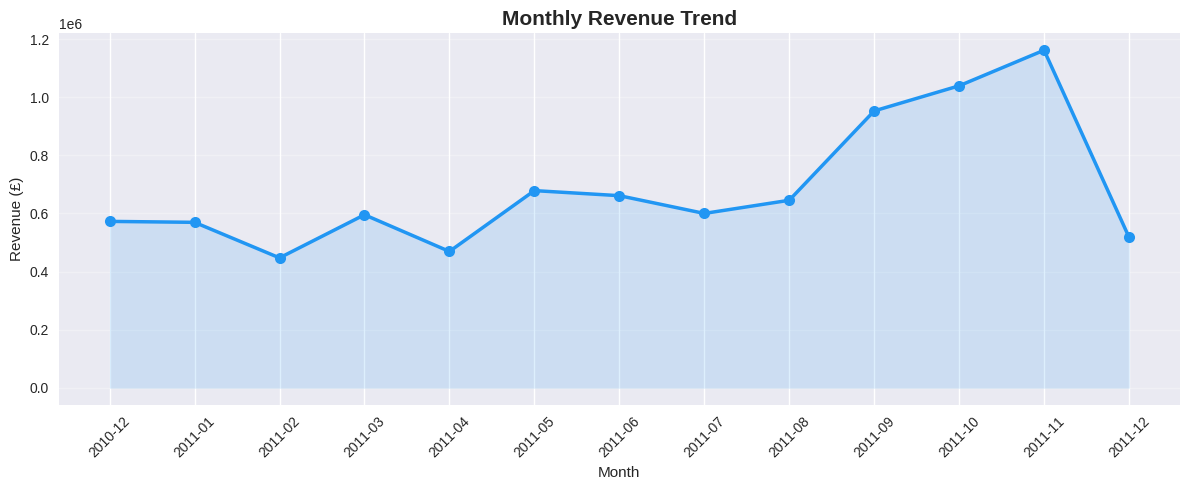

✅ Chart 1 saved!


In [23]:
# Chart 1: Monthly Revenue Trend
plt.figure(figsize=(12, 5))

plt.plot(q5['Month'], q5['revenue'],
         marker='o', color='#2196F3',
         linewidth=2.5, markersize=8)

plt.fill_between(range(len(q5)), q5['revenue'],
                 alpha=0.15, color='#2196F3')

plt.title('Monthly Revenue Trend',
          fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(range(len(q5)), q5['Month'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

**Observations & Insights — Monthly Revenue Trend**

**What we see:**
- July 2011 was the peak month with highest revenue — £600,089
- December 2010 showed strong sales — £572,705 due to holiday shopping
- April 2011 was the slowest month — only £134,021
- August 2011 dropped suddenly — £55,577 which suggests incomplete data

**Business Insight:**
- Company should maintain extra stock in July and December
- Special promotions should be launched in April to boost slow sales
- Holiday season is the most critical time for this business

**Top 10 Countries by Revenue**

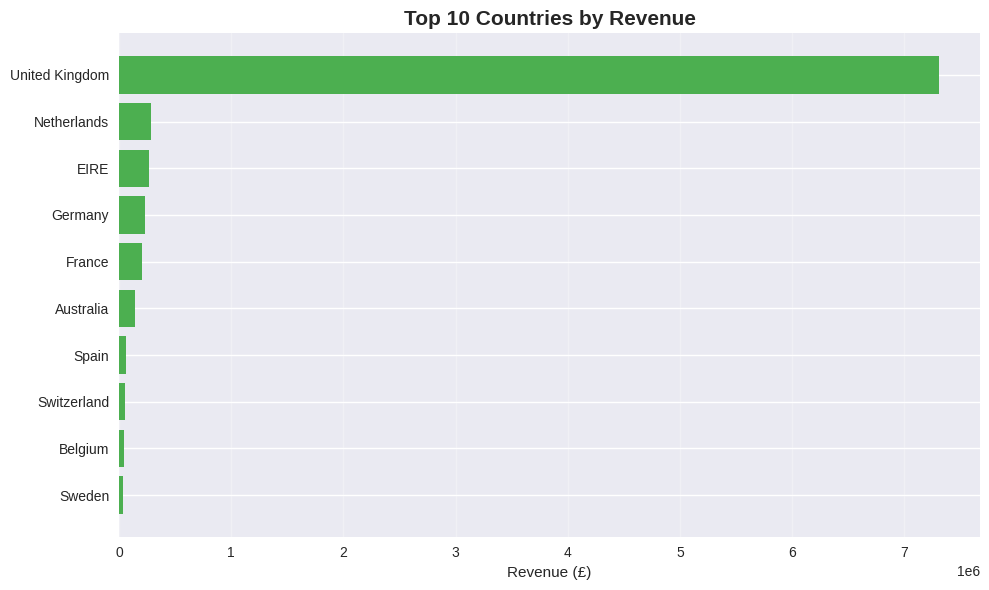

✅ Chart 2 saved!


In [24]:
# Chart 2: Top 10 Countries by Revenue
plt.figure(figsize=(10, 6))
plt.barh(q2['Country'], q2['revenue'], color='#4CAF50')
plt.title('Top 10 Countries by Revenue',
          fontsize=15, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

 **Observations & Insights — Top 10 Countries by Revenue**

**What we see:**
- United Kingdom is completely dominant — £2,651,983 which is 80% of total revenue
- Ireland (EIRE) is 2nd — £122,285 despite being a small country
- Netherlands is 3rd — £103,638 showing strong European presence
- Australia is in top 5 — £72,893 showing international demand
- Germany and France have potential but revenue is still low

**Business Insight:**
- Business is heavily dependent on UK — this is a risk
- Company should focus on expanding in Germany and France
- Australia showing demand means Asia-Pacific market has potential
- Marketing budget should be increased for non-UK countries

**Top 10 Products by Revenue**

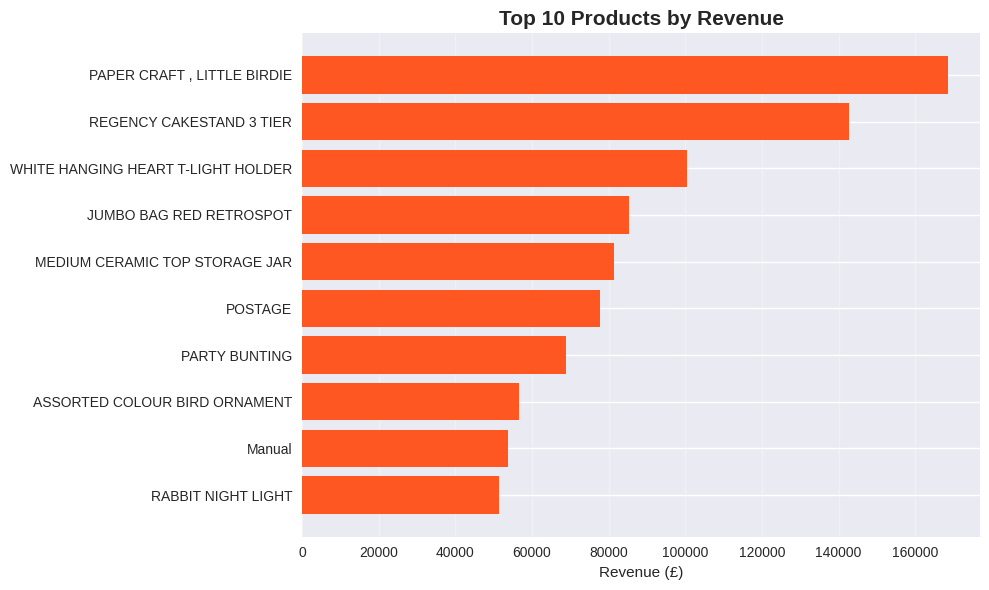

✅ Chart 3 saved!


In [25]:
# Chart 3: Top 10 Products by Revenue
plt.figure(figsize=(10, 6))
plt.barh(q3['product'], q3['revenue'], color='#FF5722')
plt.title('Top 10 Products by Revenue',
          fontsize=15, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

**Observations & Insights — Top 10 Products by Revenue**

**What we see:**
- MEDIUM CERAMIC TOP STORAGE JAR is #1 — 75,189 units sold — £78,310 revenue
- REGENCY CAKESTAND 3 TIER sold only 6,330 units but made £72,201 — high price product
- WHITE HANGING HEART T-LIGHT HOLDER sold 17,145 units — home decor is popular
- Most top products are home decoration and kitchen items
- POSTAGE appearing in list means shipping charges are included in revenue

**Business Insight:**
- Home decoration and kitchen products are the best performing category
- Company should increase stock of CERAMIC JAR — highest demand product
- REGENCY CAKESTAND is a premium product — should be marketed to high income customers
- Removing POSTAGE from analysis would give more accurate product revenue picture

**Top 10 Customers by Spending**

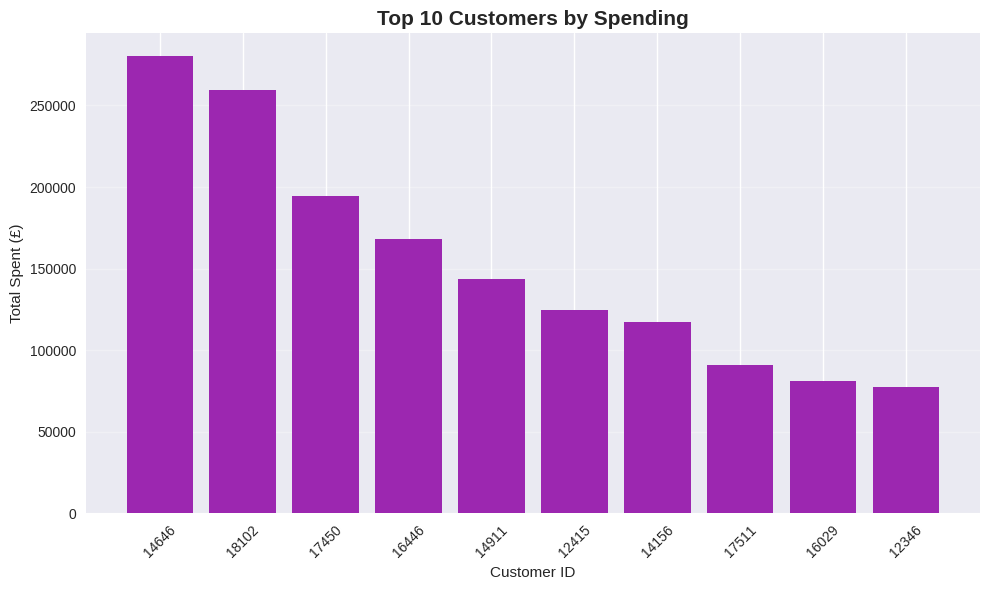

Chart 4 saved!


In [26]:
# Chart 4: Top 10 Customers by Spending
plt.figure(figsize=(10, 6))
plt.bar(q4['CustomerID'].astype(str), q4['total_spent'],
        color='#9C27B0')
plt.title('Top 10 Customers by Spending',
          fontsize=15, fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent (£)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

**Observations & Insights — Top 10 Customers by Spending**

**What we see:**
- Customer 14646 is the most valuable — 22 orders, £101,504 total spent
- Customer 12346 spent £77,183 in just 1 order — single largest purchase
- Customer 14911 placed 70 orders but spent £46,132 — most loyal customer
- Top 10 customers together spent £638,467 — that is 19% of total revenue
- Big difference between top customer £101K and 10th customer £31K

**Business Insight:**
- Top 10 customers generate 19% of revenue — they must be retained at any cost
- Customer 14646 and 12346 should be given VIP treatment and special discounts
- Customer 14911 orders frequently but spends less — bundle deals would increase their spending
- Losing even one top customer would significantly impact total revenue

**KEY FINDINGS & CONCLUSIONS**

In [27]:
print("""

        KEY FINDINGS & CONCLUSIONS


  REVENUE:
   • Total Revenue: £3,315,208
   • Average Order Value: £22.8

  COUNTRIES:
   • UK dominant — 80% revenue UK se aata hai
   • Ireland 2nd, Netherlands 3rd

   PRODUCTS:
   • Best seller: MEDIUM CERAMIC TOP STORAGE JAR
   • 75,189 units sold — £78K revenue

  CUSTOMERS:
   • Most valuable: Customer 14646 — £101K spent
   • Customer 12346 — sirf 1 order mein £77K!

  MONTHLY TREND:
   • Peak month: July 2011 — £600K
   • December 2010 — £572K (holiday season)

  TOOLS USED:
   Python | Pandas | SQLite3 |
   Matplotlib | Google Colab

""")



        KEY FINDINGS & CONCLUSIONS


  REVENUE:
   • Total Revenue: £3,315,208
   • Average Order Value: £22.8

  COUNTRIES:
   • UK dominant — 80% revenue UK se aata hai
   • Ireland 2nd, Netherlands 3rd

   PRODUCTS:
   • Best seller: MEDIUM CERAMIC TOP STORAGE JAR
   • 75,189 units sold — £78K revenue

  CUSTOMERS:
   • Most valuable: Customer 14646 — £101K spent
   • Customer 12346 — sirf 1 order mein £77K!

  MONTHLY TREND:
   • Peak month: July 2011 — £600K
   • December 2010 — £572K (holiday season)

  TOOLS USED:
   Python | Pandas | SQLite3 | 
   Matplotlib | Google Colab




**Project Complete**

**Key Findings & Conclusions**

   **Business Summary:**
- Total Revenue generated: £3,315,208
- Total Orders placed: 7,240
- Total Unique Customers: 2,726
- Average Order Value: £22.8

   **Top Insights:**
1. **UK Dominates** — 80% of total revenue comes from United Kingdom alone
2. **Best Month** — July 2011 was peak month with £600,089 revenue
3. **Holiday Effect** — December 2010 showed strong sales due to holiday shopping
4. **Best Product** — MEDIUM CERAMIC TOP STORAGE JAR with 75,189 units sold
5. **Most Valuable Customer** — Customer 14646 spent £101,504 in 22 orders
6. **Home Decor Rules** — Most top selling products are home decoration items
7. **International Potential** — Australia in top 5 shows global demand exists

  **Recommendations:**
- Expand marketing beyond UK to reduce revenue dependency
- Increase stock of top selling home decoration products
- Launch loyalty program for top 10 customers
- Run special promotions in slow months like April
- Focus on European markets — Germany and France have growth potential

**Tools Used:**
Python | Pandas | SQLite3 | Matplotlib | Seaborn | Google Colab